# XL_MOPLC Pipeline
## XL-MS-guided Monte Carlo Tree Search for Protein Complex Assembly

This notebook provides a complete, step-by-step pipeline for assembling large
protein complex structures by integrating:

- **XL-MS data** (crosslinking mass spectrometry) as spatial restraints
- **AlphaFold3 / AF3X** predictions for dimer/trimer sub-complexes
- **MCTS** (Monte Carlo Tree Search) for higher-order complex assembly

---

### Pipeline overview

| Phase | Steps | Description |
|-------|-------|-------------|
| **Pre-processing** | 1–3 | Build PPI network, enumerate sub-complexes, prepare AF3 JSONs |
| **AlphaFold prediction** | — | External step: run AF3/AF3X on generated JSON inputs |
| **Post-prediction** | 4–7 | Rewrite structures, split trimers, select representative dimers |
| **Assembly** | 8 | MCTS-based complex assembly guided by XL-MS restraints |

---

> **Before you start:**
> 1. Prepare `chains.csv` and a UniProt FASTA file (see Section 1 below).
> 2. Edit **Global Configuration** to point to your data directories.

---
## Global Configuration

Edit the **single code cell below** to point to your project directory before
running any other cell.  All other paths are derived automatically.

```
YOUR_PROJECT/
├── chains.csv                 # Gene → Chain mapping        (manually prepared)
├── <complex>.fasta            # Protein sequences           (UniProt format)
├── <xl_ms_data>.csv           # Raw XL-MS interaction table
├── <gene_list>.xlsx           # Gene → UniProt Entry table
├── binary_pairs.csv           # Binary PPI pairs            (generated – Step 2)
├── triplets.csv               # Triplets to predict         (generated – Step 2)
├── jsons/                     # AF3 JSON inputs             (generated – Step 3)
├── afx_pred/                  # AF3 / AF3X output folder    (filled externally)
└── assembled_complex/
    ├── network.csv            # Assembly network            (generated – Step 4)
    ├── useqs.csv              # Unique sequences            (generated – Step 4)
    ├── ucrosslinks.csv        # Unique crosslinks           (generated – Step 5)
    ├── rewrited_pdbs/         # Renamed PDB / JSON files   (generated – Steps 6–7)
    ├── pairs/                 # Dimer structures            (generated – Steps 8–9)
    └── output/                # Final assembled complexes   (generated – Step 10)
```

### Key parameters

| Variable | Default | Description |
|---|---|---|
| `CROSSLINKER_LENGTH` | `35` | Maximum Cα–Cα distance (Å) for a satisfied crosslink |
| `SAMPLE_TIMES` | `3` | Number of random crosslink samplings per sub-complex |
| `TRIMER_MAX_LEN` | `2500` | Max combined residues for a trimer; longer → split to dimers |


In [ ]:
import pandas as pd

# ==============================================================
# ▶ EDIT THIS SECTION before running the pipeline
# ==============================================================

# Root directory of your project data (use a raw string on Windows)
BASE_DIR = r"PATH\TO\YOUR\PROJECT"

# --- Input files (manually prepared) -------------------------
CHAINS_CSV      = f"{BASE_DIR}\\chains.csv"      # Gene → Chain mapping
FASTA_PATH      = f"{BASE_DIR}\\complex.fasta"   # UniProt FASTA
XL_MS_CSV       = f"{BASE_DIR}\\xl_ms_data.csv"  # Raw XL-MS table
GENE_LIST_EXCEL = f"{BASE_DIR}\\gene_list.xlsx"  # Gene → UniProt Entry

# --- Assembly parameters -------------------------------------
CROSSLINKER_LENGTH = 35    # Cα–Cα cut-off (Å); 35 for DSSO/DSBSO
SAMPLE_TIMES       = 3     # Random crosslink samplings per sub-complex
TRIMER_MAX_LEN     = 2500  # Residue limit for trimer; longer → split to dimers

# ==============================================================
# Derived paths (no need to edit below this line)
# ==============================================================
XL_MS_CLEANED_CSV = f"{BASE_DIR}\\xl_ms_data_cleaned.csv"
BINARY_PAIRS_CSV  = f"{BASE_DIR}\\binary_pairs.csv"
TRIPLETS_CSV      = f"{BASE_DIR}\\triplets.csv"
AF3_JSON_DIR      = f"{BASE_DIR}\\jsons"
AF_PRED_DIR       = f"{BASE_DIR}\\afx_pred"

ASSEMBLED_DIR     = f"{BASE_DIR}\\assembled_complex"
NETWORK_CSV       = f"{ASSEMBLED_DIR}\\network.csv"
USEQS_CSV         = f"{ASSEMBLED_DIR}\\useqs.csv"
UCROSSLINKS_CSV   = f"{ASSEMBLED_DIR}\\ucrosslinks.csv"
REWRITED_PDB_DIR  = f"{ASSEMBLED_DIR}\\rewrited_pdbs"
PAIRS_DIR         = f"{ASSEMBLED_DIR}\\pairs"
OUTPUT_DIR        = f"{ASSEMBLED_DIR}\\output"

# ==============================================================
# Auto-populate PROTEIN_LIST from gene_list.xlsx
# ==============================================================
import os
if os.path.exists(GENE_LIST_EXCEL):
    _gene_df     = pd.read_excel(GENE_LIST_EXCEL)
    PROTEIN_LIST = _gene_df["Gene"].dropna().tolist()
    print(f"Auto-detected {len(PROTEIN_LIST)} proteins from {GENE_LIST_EXCEL}:")
    for _g in PROTEIN_LIST:
        print(f"  {_g}")
    print()
    print("If the list is incorrect, override PROTEIN_LIST manually below:")
    print("  PROTEIN_LIST = ['GENE_A', 'GENE_B', ...]")
else:
    # Fallback: define the list manually
    PROTEIN_LIST = [
        "PROTEIN_A",
        "PROTEIN_B",
        # Add all subunit gene names here
    ]
    print("gene_list.xlsx not found — using manually defined PROTEIN_LIST.")

print(f"Configuration loaded.  Crosslinker length: {CROSSLINKER_LENGTH} Å")


---
## Step 0 · Validate Input Files

Run this cell immediately after the configuration above.  It checks that all
manually prepared input files exist and contain the required columns.  Fix any
reported issues before proceeding.


In [ ]:
import os
import pandas as pd

# ==============================================================
# Input file validation
# Checks that all required files exist and have the expected
# column structure before running any pipeline steps.
# ==============================================================

def validate_inputs(
    chains_csv: str,
    fasta_path: str,
    xl_ms_csv: str,
    gene_list_excel: str,
) -> bool:
    """
    Validate that all required input files exist and contain the
    expected columns.

    Parameters
    ----------
    chains_csv : str
        Path to chains.csv  (required columns: Gene, Chain).
    fasta_path : str
        Path to the UniProt FASTA file.
    xl_ms_csv : str
        Path to the raw XL-MS CSV  (required columns: gene_a, gene_b,
        pepA, pepB, Alpha protein(s) position(s),
        Beta protein(s) position(s)).
    gene_list_excel : str
        Path to gene_list.xlsx  (required columns: Gene, Entry).

    Returns
    -------
    bool
        True if all checks pass; False otherwise.
    """
    ok = True

    # ── Required files & their mandatory columns ──────────────
    checks = [
        (chains_csv,      "CSV",   ["Gene", "Chain"]),
        (xl_ms_csv,       "CSV",   ["gene_a", "gene_b", "pepA", "pepB",
                                     "Alpha protein(s) position(s)",
                                     "Beta protein(s) position(s)"]),
        (gene_list_excel, "Excel", ["Gene", "Entry"]),
        (fasta_path,      "FASTA", None),
    ]

    for path, fmt, required_cols in checks:
        # 1. File existence
        if not os.path.exists(path):
            print(f"  [MISSING]  {path}")
            ok = False
            continue
        print(f"  [OK]       {path}")

        # 2. Column check (CSV / Excel only)
        if required_cols is None:
            continue
        try:
            df = pd.read_csv(path) if fmt == "CSV" else pd.read_excel(path)
            missing_cols = [c for c in required_cols if c not in df.columns]
            if missing_cols:
                print(f"             ↳ Missing columns: {missing_cols}")
                ok = False
            else:
                print(f"             ↳ Columns OK {required_cols}")
        except Exception as exc:
            print(f"             ↳ Could not read file: {exc}")
            ok = False

    # ── FASTA: quick sanity check ─────────────────────────────
    if os.path.exists(fasta_path):
        with open(fasta_path) as fh:
            first_line = fh.readline().strip()
        if not first_line.startswith(">"):
            print(f"  [WARN]  {fasta_path} does not look like a FASTA file.")
            ok = False
        elif "GN=" not in first_line:
            print(f"  [WARN]  FASTA headers appear to be missing GN= fields.")
            print(f"          Gene names will not be auto-detected correctly.")

    return ok


print("Validating input files...\n")
all_ok = validate_inputs(CHAINS_CSV, FASTA_PATH, XL_MS_CSV, GENE_LIST_EXCEL)

if all_ok:
    print("\n✓ All input files look good.  You may proceed with Step 2.")
else:
    print(
        "\n✗ One or more input files are missing or malformed.\n"
        "  Please fix the issues above before continuing."
    )


---
## Imports

In [5]:
import os
import argparse
import logging
from itertools import combinations

import pandas as pd

# Network analysis and visualization
from network.interact_map import (
    load_interaction_data,
    build_ppi_network,
    clean_node_names,
    plot_ppi_network,
    analyze_complexes,
    clean_residue_pair_file,
)

# AF3 JSON preparation
from preprocess.af_json_prepare import prepare_multimer_jsons

# Network and sequence preparation
from preprocess.network_prepare import build_network_and_useqs

# Crosslink preparation
from preprocess.crosslink_prepare import crosslink_prepare

# AlphaFold structure rewriting and dimer selection
from complex_assembly.rewrite_af_files import (
    rewrite_af_cif_structure,
    rewrite_af_score_file,
    split_trimer_to_dimers,
    select_most_central_pdb,
)

# MCTS assembly
import complex_assembly.mcts as mcts

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("All modules imported successfully.")

All modules imported successfully.


---
# Phase 1 — Pre-processing
## Step 1 · Prepare Input Files (Manual)

Two files must be created manually before running the pipeline:

### `chains.csv`

Maps each gene to a unique single-letter chain identifier.

| Entry    | Gene   | Chain |
|----------|--------|-------|
| Q9NV70   | EXOC1  | A     |
| Q96KP1   | EXOC2  | B     |
| ...      | ...    | ...   |

- Column names must be exactly: `Entry`, `Gene`, `Chain`
- Chain IDs must be unique single uppercase letters (A, B, C, …)

### FASTA file

Standard UniProt format. Each header **must** contain a `GN=` field:

```
>sp|Q9NV70|EXOC1_HUMAN Exocyst complex component 1 OS=Homo sapiens GN=EXOC1 PE=1 SV=2
MMSIKAFTLVSAVERELLMG...
```

The gene name after `GN=` must match exactly with the `Gene` column in `chains.csv`.

---
## Step 2 · Build PPI Network and Enumerate Sub-complexes

We build an undirected protein–protein interaction (PPI) graph from the
raw XL-MS data, clean ambiguous node names, then enumerate all binary pairs
and trimers present in the network.

**Output files:**
- `binary_pairs.csv` — all dimer pairs supported by the PPI network  
- `triplets.csv` — all trimers with at least two edges in the PPI network

In [6]:
# Load interaction data and build the PPI network
df = load_interaction_data(XL_MS_CSV)
G = build_ppi_network(df)

# Identify nodes that need manual cleanup (contain semicolons)
dirty_nodes = [n for n in G.nodes() if ";" in str(n)]
print(f"Nodes needing cleanup ({len(dirty_nodes)}):")
for node in dirty_nodes:
    print(" ", node)

Nodes needing cleanup (0):


In [7]:
# Define a manual mapping to clean ambiguous node names.
# Add entries for each "dirty" node printed above.
# Example:
#   manual_map = {
#       'COPB2; COPB2': 'COPB2',
#       'ARF4; ARF6; ARF1; ARF5': 'ARF1',
#   }

manual_map = {
    # 'DIRTY_NAME': 'CLEAN_NAME',
}

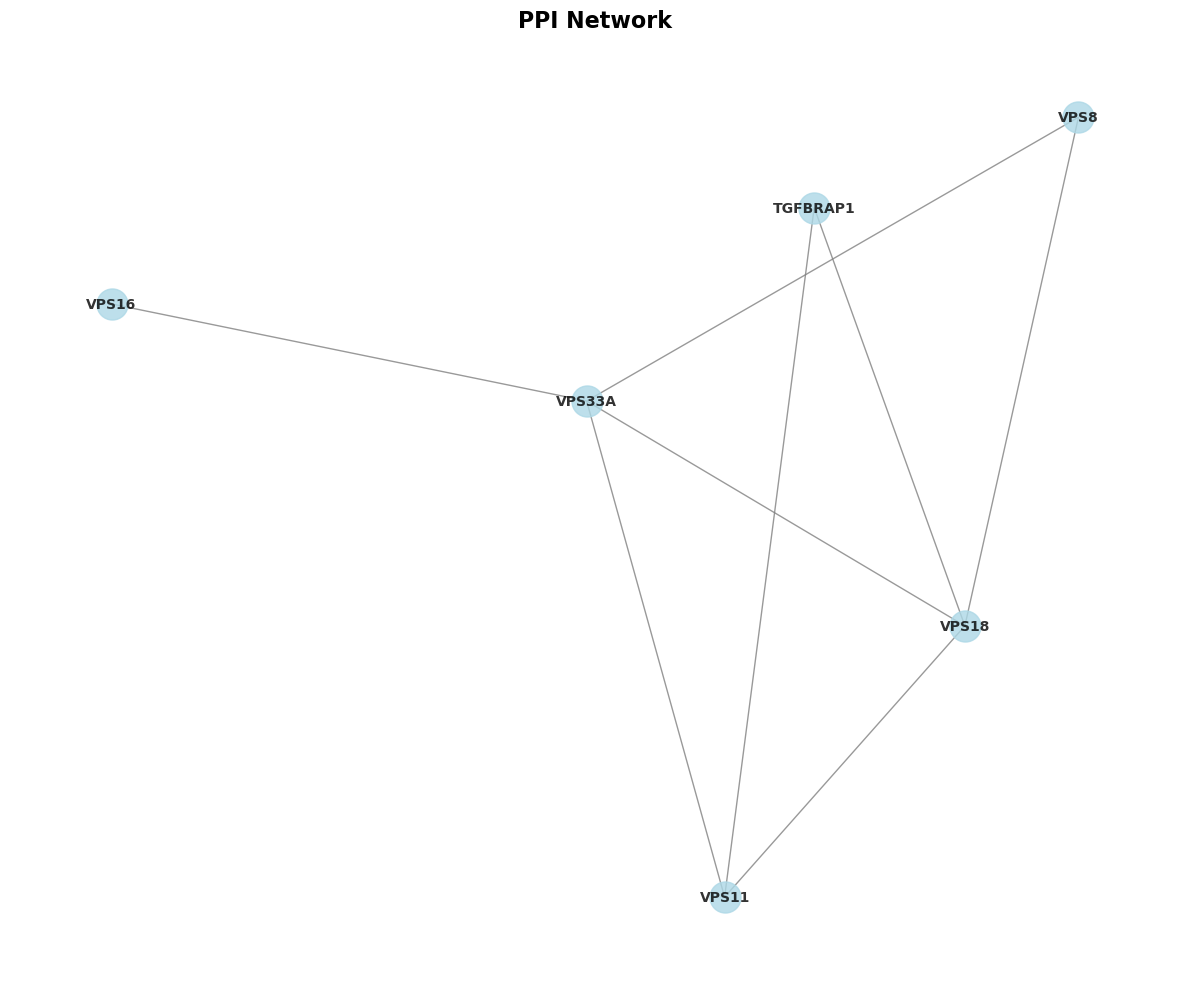

Cleaned file written to: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\xl_ms_data_cleaned.csv
Cleaned XL-MS file: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\xl_ms_data_cleaned.csv


In [8]:
# Apply cleaning and visualize the network
G = clean_node_names(G, manual_map)
plot_ppi_network(G, "PPI Network")

# Rewrite the raw XL-MS file with cleaned names (saves to *_cleaned.csv)
clean_residue_pair_file(XL_MS_CSV, manual_map)
print(f"Cleaned XL-MS file: {XL_MS_CLEANED_CSV}")

In [9]:
# Enumerate binary pairs and trimers from the target protein list
os.makedirs(OUTPUT_DIR, exist_ok=True)

dimer_in_ppi, trimer_in_ppi = analyze_complexes(G, PROTEIN_LIST)

df_dimers  = pd.DataFrame(set(dimer_in_ppi),  columns=["p1", "p2"])
df_trimers = pd.DataFrame(set(trimer_in_ppi), columns=["p1", "p2", "p3"])

df_dimers.to_csv(BINARY_PAIRS_CSV, index=False)
df_trimers.to_csv(TRIPLETS_CSV, index=False)

total_triplets = len(list(combinations(PROTEIN_LIST, 3)))
print(f"Total possible triplets : {total_triplets}")
print(f"Triplets found in PPI   : {len(trimer_in_ppi)}")
print(f"Binary pairs found      : {len(set(dimer_in_ppi))}")
print(f"Saved: {BINARY_PAIRS_CSV}")
print(f"Saved: {TRIPLETS_CSV}")

Total possible triplets : 20
Triplets found in PPI   : 11
Binary pairs found      : 8
Saved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\binary_pairs.csv
Saved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\triplets.csv


---
## Step 3 · Prepare AlphaFold3 Input JSONs

For each triplet (or dimer if too long), we generate one JSON file per
random crosslink sampling. By default, three samplings are produced.

### Required `gene_list.xlsx` format

| Entry    | Gene   | Anno          |
|----------|--------|---------------|
| Q9NV70   | EXOC1  | Exocyst complex |
| Q96KP1   | EXOC2  | Exocyst complex |

### Required XL-MS CSV columns

| gene_a | gene_b | pepA | pepB | ... |
|--------|--------|------|------|-----|
| EXOC1  | EXOC2  | `QRAVEAQ[K]LMK` | `VVSN[K]LEEK` | ... |

In [ ]:
prepare_multimer_jsons(
    raw_crosslink_csv = XL_MS_CLEANED_CSV,
    fasta_file        = FASTA_PATH,
    gene_list_excel   = GENE_LIST_EXCEL,
    triplet_csv       = TRIPLETS_CSV,
    output_dir        = AF3_JSON_DIR,
    sample_times      = SAMPLE_TIMES,
    trimer_max_len    = TRIMER_MAX_LEN,
)
print(f"JSON files written to: {AF3_JSON_DIR}")


---
## ⚠️ External Step — Run AlphaFold3 / AF3X

Before continuing, run AlphaFold3 or AF3X on the JSON files generated above:

```bash
# Example using AF3X
af3x --input_dir  /path/to/jsons/ \
     --output_dir /path/to/afx_pred/ \
     --model_dir  /path/to/af3_model/
```

- [AlphaFold3](https://github.com/google-deepmind/alphafold3)
- [AF3X](https://github.com/KosinskiLab/af3x)

Place the prediction output in `AF_PRED_DIR` (configured above), then
continue from Phase 2.

---
# Phase 2 — Post-prediction Processing
## Step 4 · Build Assembly Network and Sequence Table

Generate `network.csv` (chain connectivity) and `useqs.csv` (chain sequences)
from the binary PPI pairs, `chains.csv`, and the FASTA file.

**Output files:**
- `network.csv` — columns: `Chain1`, `Chain2`, `Source`
- `useqs.csv`   — columns: `Chain`, `Useq` (gene name), `Sequence`

In [12]:
os.makedirs(ASSEMBLED_DIR, exist_ok=True)

network_df, useq_df = build_network_and_useqs(
    binary_csv  = BINARY_PAIRS_CSV,
    chains_csv  = CHAINS_CSV,
    fasta_file  = FASTA_PATH,
    network_out = NETWORK_CSV,
    useqs_out   = USEQS_CSV,
)

print(f"Network entries : {len(network_df)}")
print(f"Unique sequences: {len(useq_df)}")
print(f"Saved: {NETWORK_CSV}")
print(f"Saved: {USEQS_CSV}")
useq_df.head()

Network entries : 8
Unique sequences: 6
Saved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\network.csv
Saved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\useqs.csv


,Chain,Useq,Sequence
0,A,TGFBRAP1,MMSIKAFTLVSAVERELLMGDKERVNIECVECCGRDLYVGTNDCFV...
1,B,VPS11,MAAYLQWRRFVFFDKELVKEPLSNDGAAPGATPASGSAASKFLCLP...
2,C,VPS16,MDCYTANWNPLGDSAFYRKYELYSMDWDLKEELRDCLVAAAPYGGP...
3,D,VPS18,MASILDEYENSLSRSAVLQPGCPSVGIPHSGYVNAQLEKEVPIFTK...
4,E,VPS33A,MAAHLSYGRVNLNVLREAVRRELREFLDKCAGSKAIVWDEYLTGPF...


---
## Step 5 · Prepare Crosslink Constraints

Map raw XL-MS residue pairs onto chain/residue identifiers from `useqs.csv`.

**Output file:** `ucrosslinks.csv` — columns: `ChainA`, `ResidueA`, `ChainB`, `ResidueB`

In [13]:
useq_df         = pd.read_csv(USEQS_CSV)
residue_pair_df = pd.read_csv(XL_MS_CLEANED_CSV)

ucrosslinks = crosslink_prepare(useq_df, residue_pair_df)
ucrosslinks.to_csv(UCROSSLINKS_CSV, index=False)

print(f"Unique crosslinks: {len(ucrosslinks)}")
print(f"Saved: {UCROSSLINKS_CSV}")
ucrosslinks.head()

Unique crosslinks: 85
Saved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\ucrosslinks.csv


,ChainA,ResidueA,ChainB,ResidueB
0,B,475,B,477
1,A,334,D,130
2,D,910,F,1266
3,B,120,E,313
4,A,630,A,647


---
## Step 6 · Rewrite AlphaFold Structures

Convert AlphaFold CIF outputs to PDB format with standardised chain IDs
matching `chains.csv`. Non-protein residues (ligands, ions, water) are
removed.

> If interrupted, simply re-run the cell — already completed structures are
> skipped automatically.

In [18]:
rewrite_af_cif_structure(
    af_pred_folder = AF_PRED_DIR,
    chains_df_path = CHAINS_CSV,
    output_folder  = REWRITED_PDB_DIR,
)
print(f"Rewritten PDB files in: {REWRITED_PDB_DIR}")

Gene -> Chain mapping: {'tgfbrap1': 'A', 'vps11': 'B', 'vps16': 'C', 'vps18': 'D', 'vps33a': 'E', 'vps8': 'F'}
Folder: tgfbrap1_vps11_vps18_0, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}


c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `D` is already used for a sibling of this entity. Changing id from `C` to `D` might create access inconsistencies to children of the parent entity.
  warnings.warn(


Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\tgfbrap1_vps11_vps18_0\tgfbrap1_vps11_vps18_0.pdb
Folder: tgfbrap1_vps11_vps18_1, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}


c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `D` is already used for a sibling of this entity. Changing id from `C` to `D` might create access inconsistencies to children of the parent entity.
  warnings.warn(


Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\tgfbrap1_vps11_vps18_1\tgfbrap1_vps11_vps18_1.pdb
Folder: tgfbrap1_vps11_vps18_2, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}


...

Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps16_vps18_vps33a_0\vps16_vps18_vps33a_0.pdb
Folder: vps16_vps18_vps33a_1, mapping: {'A': 'C', 'B': 'D', 'C': 'E'}


c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `C` is already used for a sibling of this entity. Changing id from `A` to `C` might create access inconsistencies to children of the parent entity.
  warnings.warn(
c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `D` is already used for a sibling of this entity. Changing id from `B` to `D` might create access inconsistencies to children of the parent entity.
  warnings.warn(
c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `E` is already used for a sibling of this entity. Changing id from `C` to `E` might create access inconsistencies to children of the parent entity.
  warnings.warn(


Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps16_vps18_vps33a_1\vps16_vps18_vps33a_1.pdb
Folder: vps16_vps18_vps33a_2, mapping: {'A': 'C', 'B': 'D', 'C': 'E'}


c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `C` is already used for a sibling of this entity. Changing id from `A` to `C` might create access inconsistencies to children of the parent entity.
  warnings.warn(
c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `D` is already used for a sibling of this entity. Changing id from `B` to `D` might create access inconsistencies to children of the parent entity.
  warnings.warn(
c:\Users\zhang.zehong\AppData\Local\anaconda3\envs\xl_complex_structure\Lib\site-packages\Bio\PDB\Entity.py:197: BiopythonWarning: The id `E` is already used for a sibling of this entity. Changing id from `C` to `E` might create access inconsistencies to children of the parent entity.
  warnings.warn(


Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps16_vps18_vps33a_2\vps16_vps18_vps33a_2.pdb
Folder: vps33a_vps8_0, mapping: {'A': 'E', 'B': 'F'}
Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps33a_vps8_0\vps33a_vps8_0.pdb
Folder: vps33a_vps8_1, mapping: {'A': 'E', 'B': 'F'}
Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps33a_vps8_1\vps33a_vps8_1.pdb
Folder: vps33a_vps8_2, mapping: {'A': 'E', 'B': 'F'}
Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps33a_vps8_2\vps33a_vps8_2.pdb
Folder: vps8_vps18_0, mapping: {'A': 'F', 'B': 'D'}
Saved rewritten PDB: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\rewrited_pdbs\vps8_vps18_0\vps8_vps18_0.pdb
Folder: vps8_vps18_1, mapping: {'A': 'F', 'B': 

---
## Step 7 · Rewrite AlphaFold Confidence Files

Update confidence JSON files with renamed chain IDs and truncate PAE /
contact-probability matrices to protein-only tokens.

In [19]:
rewrite_af_score_file(
    af_pred_folder = AF_PRED_DIR,
    chains_df_path = CHAINS_CSV,
    output_folder  = REWRITED_PDB_DIR,
)
print(f"Confidence files updated in: {REWRITED_PDB_DIR}")

Gene -> Chain mapping: {'tgfbrap1': 'A', 'vps11': 'B', 'vps16': 'C', 'vps18': 'D', 'vps33a': 'E', 'vps8': 'F'}
Folder: tgfbrap1_vps11_vps18_0, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}
Folder: tgfbrap1_vps11_vps18_1, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}
Folder: tgfbrap1_vps11_vps18_2, mapping: {'A': 'A', 'B': 'B', 'C': 'D'}
Folder: tgfbrap1_vps11_vps33a_0, mapping: {'A': 'A', 'B': 'B', 'C': 'E'}
Folder: tgfbrap1_vps11_vps33a_1, mapping: {'A': 'A', 'B': 'B', 'C': 'E'}
Folder: tgfbrap1_vps11_vps33a_2, mapping: {'A': 'A', 'B': 'B', 'C': 'E'}
Folder: tgfbrap1_vps18_vps33a_0, mapping: {'A': 'A', 'B': 'D', 'C': 'E'}
Folder: tgfbrap1_vps18_vps33a_1, mapping: {'A': 'A', 'B': 'D', 'C': 'E'}
Folder: tgfbrap1_vps18_vps33a_2, mapping: {'A': 'A', 'B': 'D', 'C': 'E'}
Folder: vps11_vps16_vps33a_0, mapping: {'A': 'B', 'B': 'C', 'C': 'E'}
Folder: vps11_vps16_vps33a_1, mapping: {'A': 'B', 'B': 'C', 'C': 'E'}
Folder: vps11_vps16_vps33a_2, mapping: {'A': 'B', 'B': 'C', 'C': 'E'}
Folder: vps11_vps18_vps33

---
## Step 8 · Split Trimers into Dimers

Decompose each 3-chain AlphaFold prediction into all three dimer pairs.
2-chain predictions are copied directly.
Both the PDB structure and confidence JSON are split per dimer.

> Progress is checkpointed to `split_progress.json` — safe to restart.

In [20]:
split_trimer_to_dimers(
    rewrited_pdb_folder = REWRITED_PDB_DIR,
    output_folder       = PAIRS_DIR,
)
print(f"Dimer pairs written to: {PAIRS_DIR}")

[DONE] tgfbrap1_vps11_vps18_0
[DONE] tgfbrap1_vps11_vps18_1
[DONE] tgfbrap1_vps11_vps18_2
[DONE] tgfbrap1_vps11_vps33a_0
[DONE] tgfbrap1_vps11_vps33a_1
[DONE] tgfbrap1_vps11_vps33a_2
[DONE] tgfbrap1_vps18_vps33a_0
[DONE] tgfbrap1_vps18_vps33a_1
[DONE] tgfbrap1_vps18_vps33a_2
[DONE] vps11_vps16_vps33a_0
[DONE] vps11_vps16_vps33a_1
[DONE] vps11_vps16_vps33a_2
[DONE] vps11_vps18_vps33a_0
[DONE] vps11_vps18_vps33a_1
[DONE] vps11_vps18_vps33a_2
[DONE] vps16_vps18_vps33a_0
[DONE] vps16_vps18_vps33a_1
[DONE] vps16_vps18_vps33a_2
[DONE] vps33a_vps8_0
[DONE] vps33a_vps8_1
[DONE] vps33a_vps8_2
[DONE] vps8_vps18_0
[DONE] vps8_vps18_1
[DONE] vps8_vps18_2
All done!
Dimer pairs written to: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs


---
## Step 9 · Select Representative Dimer Structures

For each protein pair, multiple dimer models may exist (from different trimer
seeds). We select the most central structure — the one with the lowest
mean Cα RMSD to all other candidates — as the representative for assembly.

All candidates are archived in an `all/` subfolder.

In [21]:
select_most_central_pdb(PAIRS_DIR)
print(f"Representative dimers selected in: {PAIRS_DIR}")

[PROCESS] AB
Moved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\AB-1_confidences.json -> N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\all
Moved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\AB-2_confidences.json -> N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\all
Moved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\AB-3_confidences.json -> N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\all
Moved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\AB-4_confidences.json -> N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\all
Moved: N:\08_NK_structure_prediction\Claude_XL_MOPLC\data\test_data\assembled_complex\pairs\AB\AB-5_confidences.json -> N:\08_NK_structure_

---
# Phase 3 — Complex Assembly
## Step 10 · MCTS-Based Complex Assembly

The MCTS algorithm builds the full complex by iteratively adding chains via
pre-computed dimer superpositions:

1. **Selection** — UCB1 guides the tree traversal to promising partial assemblies.
2. **Expansion** — a new chain is docked using structural superposition of the
   shared (edge) chain from a pre-computed dimer.
3. **Clash filtering** — assemblies where > 50 % of Cα atoms of the new chain
   lie within 5 Å of an existing chain are discarded.
4. **Scoring** — each assembly is evaluated by a composite metric:
   - `Score_struct` = Σ log₁₀(n_contacts + 1) × mean interface pLDDT
   - `Score_XL` = fraction of crosslinks with Cα–Cα ≤ `CROSSLINKER_LENGTH`
   - `Score_final` = `Score_struct` × `Score_XL`
5. **Backpropagation** — rollout scores are propagated back to the root.

MCTS is run independently from every chain as root; the globally
highest-scoring assembly is written to `OUTPUT_DIR`.

**Outputs:** `best_complex.pdb`, `optimal_path.csv`, `mcts_run.log`

> **Crosslinker length:** The `CROSSLINKER_LENGTH` parameter (set in the
> Global Configuration cell) controls the Cα–Cα distance threshold.
> Use 35 Å for DSSO / DSBSO crosslinkers, or adjust for other reagents.


In [ ]:
import argparse
os.makedirs(OUTPUT_DIR, exist_ok=True)

args = argparse.Namespace(
    network            = NETWORK_CSV,
    pairdir            = PAIRS_DIR,
    useqs              = USEQS_CSV,
    ucrosslinks        = UCROSSLINKS_CSV,
    outdir             = OUTPUT_DIR,
    crosslinker_length = CROSSLINKER_LENGTH,
)

mcts.main(args)
print(f"\nAssembly completed.  Results in: {OUTPUT_DIR}")


---
## Step 11 · Inspect Results

List top-ranked complex PDB files from the output directory.

In [23]:
import glob

pdb_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.pdb")))
print(f"Found {len(pdb_files)} assembled complex PDB(s):")
for p in pdb_files:
    size_kb = os.path.getsize(p) / 1024
    print(f"  {os.path.basename(p):50s}  {size_kb:.1f} KB")

Found 1 assembled complex PDB(s):
  best_complex.pdb                                    3557.3 KB


---
## Summary

The **XL_MOPLC** pipeline integrates XL-MS restraints, AlphaFold3 structural
predictions, and Monte Carlo Tree Search to produce ranked atomic models of
large multi-subunit protein complexes.

| Step | Module / Function | Output |
|------|-------------------|--------|
| 0 | `validate_inputs()` | Validation report |
| 1 | Manual | `chains.csv`, `complex.fasta` |
| 2 | `interact_map` | `binary_pairs.csv`, `triplets.csv` |
| 3 | `af_json_prepare.prepare_multimer_jsons` | `jsons/*.json` |
| — | AlphaFold3 / AF3X *(external)* | `afx_pred/` |
| 4 | `network_prepare.build_network_and_useqs` | `network.csv`, `useqs.csv` |
| 5 | `crosslink_prepare.crosslink_prepare` | `ucrosslinks.csv` |
| 6 | `rewrite_af_files.rewrite_af_cif_structure` | `rewrited_pdbs/*.pdb` |
| 7 | `rewrite_af_files.rewrite_af_score_file` | `rewrited_pdbs/*_AdjustedConfidences.json` |
| 8 | `rewrite_af_files.split_trimer_to_dimers` | `pairs/*/` |
| 9 | `rewrite_af_files.select_most_central_pdb` | `pairs/*/<best>.pdb` |
| 10 | `mcts.main` | `output/best_complex.pdb`, `output/optimal_path.csv` |

### Key scoring equations

$$\text{Score}_\text{struct} = \sum_{i<j} \log_{10}(n_{ij}+1) \cdot \overline{\text{pLDDT}}_{ij}$$

$$\text{Score}_\text{XL} = \frac{|\{(a,b)\,:\,d_{ab}^{C\alpha} \leq L\}|}{N_\text{XL}}$$

$$\text{Score}_\text{final} = \text{Score}_\text{struct} \times \text{Score}_\text{XL}$$

where $n_{ij}$ is the number of Cβ–Cβ contacts between chains $i$ and $j$,
$\overline{\text{pLDDT}}_{ij}$ is the mean pLDDT over those contact residues,
$d_{ab}^{C\alpha}$ is the Cα–Cα distance between crosslinked residues $a$ and
$b$, $L$ is `CROSSLINKER_LENGTH`, and $N_\text{XL}$ is the total number of
crosslinks.

---
*XL_MOPLC · Zehong Zhang · FMP Berlin · zhang@fmp-berlin.de*
